<a href="https://colab.research.google.com/github/irajamuller/error_corrections/blob/main/UA3_UA4_Estabilizadores_Bit_flip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_aer pylatexenc --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.0 MB/s eta 0:00:00


In [2]:
# Classes do qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator, Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram, array_to_latex

import numpy as np

In [114]:
def create_repetition_code_stabilizers(initial_state='0', inject_error: int = 0):
    q_codes   = QuantumRegister(3, 'code')
    q_ancilla = QuantumRegister(2, 'ancilla')
    c_syndrome = ClassicalRegister(2, 'syndrome')
    logical_bit = ClassicalRegister(1, 'logical bit')

    qc = QuantumCircuit(q_codes, q_ancilla, c_syndrome, logical_bit)

    # ─── 1. CODIFICAÇÃO: |psi⟩ → |psi_L⟩  ──────────────────────────
    qc.barrier(label='|psi>')
    if initial_state != '0':
      qc.x(q_codes[0])

    # CNOT transversal
    qc.cx(q_codes[0], q_codes[1])   # espalha o bit lógico
    qc.cx(q_codes[0], q_codes[2])   # para os outros qubits físicos

    # ─── 2. INJEÇÃO DE ERRO (Bit-flip no qubit 0) ───────────────────────
    qc.barrier(label='Injeção Erro X')
    if not inject_error is None:
      qc.x(q_codes[inject_error])

    # ─── 4. MEDIÇÃO DOS ESTABILIZADORES (Portas Clifford) ───────────────
    qc.barrier(label='stabilizers')

    # --- Estabilizador S1 = Z1 Z2 ---
    qc.h(q_ancilla[0])                  # ancilla[0] → |+⟩
    qc.cz(q_ancilla[0], q_codes[0])     # CZ para Z1
    qc.cz(q_ancilla[0], q_codes[1])     # CZ para Z2
    qc.h(q_ancilla[0])                  # base X
    qc.measure(q_ancilla[0], c_syndrome[0]) # mede s1
    qc.barrier()
    # --- Estabilizador S2 = Z2 Z3 ---
    qc.h(q_ancilla[1])                     # ancilla[1] → |+⟩
    qc.cz(q_ancilla[1], q_codes[1])         # CZ para Z2
    qc.cz(q_ancilla[1], q_codes[2])         # CZ para Z3
    qc.h(q_ancilla[1])                      # base X
    qc.measure(q_ancilla[1], c_syndrome[1]) # mede s2

    # ─── 5. CORREÇÃO CONDICIONAL (Feed-forward) ─────────────────────────
    # syndrome = 01 (1) → erro no qubit 0
    # syndrome = 11 (3) → erro no qubit 1
    # syndrome = 10 (2) → erro no qubit 2
    qc.barrier(label='Correção')
    with qc.if_test((c_syndrome, 1)):
        qc.x(q_codes[0])
    with qc.if_test((c_syndrome, 3)):
        qc.x(q_codes[1])
    with qc.if_test((c_syndrome, 2)):
        qc.x(q_codes[2])

    # ─── 7. DECODIFICAÇÃO: |000⟩ → |0⟩ ─────────────────────────────────
    qc.barrier(label='Decodificação')
    qc.cx(q_codes[0], q_codes[2])
    qc.cx(q_codes[0], q_codes[1])

    # ─── 8. MEDIÇÃO FINAL ───────────────────────────────────────────────
    qc.barrier(label='Medição')
    qc.measure(q_codes[0], logical_bit[0])

    return qc

In [111]:
qc = create_repetition_code_stabilizers()

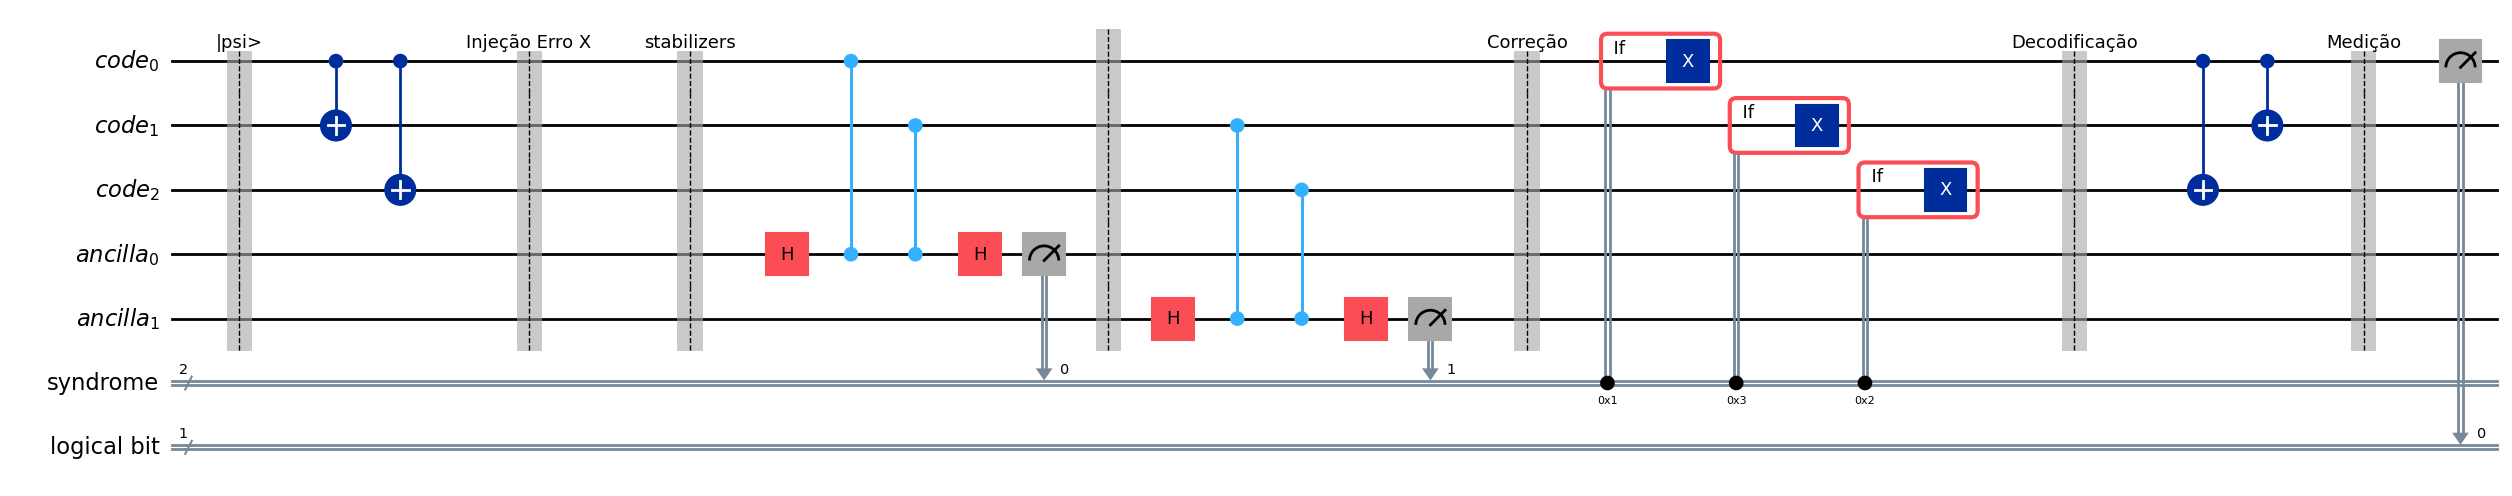

In [112]:
qc.draw('mpl', fold=-1)

In [115]:
cenarios = [
    ("Sem erro   (|0_L⟩)", '0', None),
    ("Sem erro   (|1_L⟩)", '1', None),
    ("Erro q[0]  (|0_L⟩)", '0', 0),
    ("Erro q[1]  (|0_L⟩)", '0', 1),
    ("Erro q[2]  (|0_L⟩)", '0', 2),
]

backend = AerSimulator()
for label, state, err in cenarios:
    qc = create_repetition_code_stabilizers(initial_state=state, inject_error=err)

    result  = backend.run(transpile(qc, backend), shots=1024).result()
    counts  = result.get_counts()
    print(f"{label} Contagens: {counts}")

Sem erro   (|0_L⟩) Contagens: {'0 00': 1024}
Sem erro   (|1_L⟩) Contagens: {'1 00': 1024}
Erro q[0]  (|0_L⟩) Contagens: {'0 01': 1024}
Erro q[1]  (|0_L⟩) Contagens: {'0 11': 1024}
Erro q[2]  (|0_L⟩) Contagens: {'0 10': 1024}
